# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [1]:
# !pip install peft==0.13.2, transformers==4.41.1

In [2]:
# !pip install wordcloud

In [3]:
# !pip install imblearn

In [4]:
# !pip install lightgbm

In [5]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, Tuple, Optional, List

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    f1_score, roc_curve, auc, accuracy_score,
)
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoTokenizer, AutoModel,
    AlbertModel, )

# ── Notebook setup ───────────────────────────────────────
warnings.filterwarnings("ignore")


## 1.2 Seed \& Device

In [6]:
# One notebook copy per training seed. Change RUN_SEED only.
RUN_SEED = 2025

# Fixed R0 data constant, independent of the training seed.
SPLIT_SHUFFLE_SEED = 2025

SEED = RUN_SEED

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Run seed: {RUN_SEED} | split shuffle: {SPLIT_SHUFFLE_SEED} | Device: {DEVICE}")


Run seed: 2025 | split shuffle: 2025 | Device: cuda


## 1.3 Configuration

In [ ]:
REPO_ROOT = Path(os.environ.get("MENTALHEALTH_REPO_ROOT", Path.cwd())).expanduser().resolve()
DATA_ROOT = Path(os.environ.get("MENTALHEALTH_DATA_ROOT", REPO_ROOT / "0. Dataset")).expanduser().resolve()
OUTPUT_ROOT = Path(os.environ.get("MENTALHEALTH_OUTPUT_ROOT", REPO_ROOT / "outputs")).expanduser().resolve()
RAW_DATA_FILE = "mental_health_unified_labels_final.csv"
OUTPUT_DIR = "06_AspectLabel"

ALBERT_MODEL_NAME = "albert-base-v2"
BIOBERT_MODEL_NAME = "dmis-lab/biobert-v1.1"

TEXT_COLUMN = "statement"

# ── Aspect labels (3-class each: NONE / WEAK / CLEAR) ───
ASPECT_NAMES = [
    "u_depression_strength", "u_anxiety_strength", "u_suicidal_strength",
    "u_stress_strength", "u_bipolar_strength", "u_personality_disorder_strength",
]
ASPECT_CLASSES = ["NONE", "WEAK", "CLEAR"]   # ordinal: 0 < 1 < 2
NUM_ASPECT_CLASSES = len(ASPECT_CLASSES)
ASPECT_LABEL_MAP = {v: i for i, v in enumerate(ASPECT_CLASSES)}

# ── Training config ──────────────────────────────────────
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128                   # A100: large batches to saturate GPU

RANDOM_STATE = 42
PATIENCE = 3
NUM_WORKERS = 2   # same as the R0 hard transformer loaders

# ── A100 optimizations ──────────────────────────────────

USE_COMPILE = hasattr(torch, "compile")  # PyTorch 2.0+


# ── Loss weights (λ) — equal weighting across conditions ─
LOSS_WEIGHTS = {
    "u_depression_strength": 1.0,
    "u_anxiety_strength": 1.0,
    "u_suicidal_strength": 1.0,
    "u_stress_strength": 1.0,
    "u_bipolar_strength": 1.0,
    "u_personality_disorder_strength": 1.0,
}

# ── Retrain flag ─────────────────────────────────────────
# R0 hard-style transformer random search. Same search budget and ranges as R0 hard.
N_ITERATIONS = 10
TRANSFORMER_PARAM_SPACE = {
    "lr": (np.log10(1e-5), np.log10(3e-5)),
    "epochs": (4, 10),
    "dropout": (0.0, 0.25),
}

# Optimizer settings match the hard-label arm; only the target representation
# and loss differ between the modeling branches.
USE_FP16 = torch.cuda.is_available()
USE_ONECYCLE = True
ONECYCLE_PCT_START = 0.1
MAX_GRAD_NORM = 1.0

RETRAIN = True

# ── Derived paths ────────────────────────────────────────
RAW_DATA_PATH = DATA_ROOT / "analysis_ready" / RAW_DATA_FILE
OUTPUT_PATH = OUTPUT_ROOT / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "albert": {
        "model":  OUTPUT_PATH / "best_albert_aspect.pth",
        "params": OUTPUT_PATH / "best_albert_aspect_params.json",
    },
    "biobert": {
        "model":  OUTPUT_PATH / "best_biobert_aspect.pth",
        "params": OUTPUT_PATH / "best_biobert_aspect_params.json",
    },
}

print("--- Aspect-Only Multi-Task Configuration (Mental Health) ---")
print(f"  Output     : {OUTPUT_PATH}")
print(f"  Aspects    : {ASPECT_NAMES} × {NUM_ASPECT_CLASSES} classes")
print(f"  Classes    : {ASPECT_CLASSES}")
print(f"  Loss wts   : {LOSS_WEIGHTS}")
print(f"  Batch size : {BATCH_SIZE}")

## 1.4 Mount drive & Load the data

In [ ]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {RAW_DATA_PATH}. Download the OSF data package "
        "into 0. Dataset/ or set MENTALHEALTH_DATA_ROOT."
    )

df_raw = pd.read_csv(RAW_DATA_PATH, index_col=0)
print(f"Loaded {df_raw.shape[0]} rows.")

df_raw.head()


In [9]:
# ── SCOPE GATE: keep only evaluable posts ────────────────
SPECIAL_LABELS = {"OUT_OF_SCOPE", "INSUFFICIENT"}
before = len(df_raw)
df_raw = df_raw[~df_raw["u_label"].isin(SPECIAL_LABELS)].reset_index(drop=True)
print(f"Scope gating: {before} → {len(df_raw)} rows "
      f"(removed {before - len(df_raw)} OUT_OF_SCOPE/INSUFFICIENT)")

df_raw.head()

In [10]:
# Fixed R0 data constant. Must not follow RUN_SEED.
df_raw = shuffle(df_raw, random_state=SPLIT_SHUFFLE_SEED).reset_index(drop=True)


# 2. Data Exploration \& Master Data Preparation

## 2.1 Master Data Preparation

### 2.1.1 Text cleaning

In [11]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


### 2.1.2 Validate & encode aspect labels

In [12]:
print("\nCondition strength label distributions:")
for asp in ASPECT_NAMES:
    if asp not in df_clean.columns:
        raise ValueError(f"Missing column: {asp}")

    # Coerce to uppercase string for consistent matching
    df_clean[asp] = df_clean[asp].astype(str).str.upper().str.strip()

    # Validate against ASPECT_CLASSES (NONE / WEAK / CLEAR)
    valid_mask = df_clean[asp].isin(ASPECT_CLASSES)
    n_invalid = (~valid_mask).sum()
    if n_invalid > 0:
        print(f"  WARNING: {asp} has {n_invalid} invalid values — setting to NONE")
        df_clean.loc[~valid_mask, asp] = "NONE"

    # Encode to integer using ASPECT_LABEL_MAP
    df_clean[f"{asp}_idx"] = df_clean[asp].map(ASPECT_LABEL_MAP)
    print(f"  {asp}: {df_clean[asp].value_counts().to_dict()}")


Condition strength label distributions:
  u_depression_strength: {'NONE': 32447, 'CLEAR': 17870, 'WEAK': 2726}
  u_anxiety_strength: {'NONE': 41826, 'CLEAR': 9439, 'WEAK': 1778}
  u_suicidal_strength: {'NONE': 39832, 'CLEAR': 12311, 'WEAK': 900}
  u_stress_strength: {'NONE': 42864, 'WEAK': 5887, 'CLEAR': 4292}
  u_bipolar_strength: {'NONE': 51190, 'CLEAR': 1405, 'WEAK': 448}
  u_personality_disorder_strength: {'NONE': 51798, 'WEAK': 684, 'CLEAR': 561}


## 2.3 Master Data Split

In [13]:
# Use first condition as stratification proxy
y_for_split = df_clean[f"{ASPECT_NAMES[0]}_idx"]
groups = df_clean[TEXT_COLUMN]

# 80/20 → train+val / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y_for_split, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# train → train + val (75/25 of 80% = 60/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval[f"{ASPECT_NAMES[0]}_idx"],
                  groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split
# Stable pairing key, identical to the "id" column the hard-label notebooks
# export. Cleaned text is not unique across the test set, so merging on text
# alone is unsafe.
df_clean["id"] = np.arange(len(df_clean), dtype=np.int64)

print("\nSplit counts:")
print(df_clean["split"].value_counts())

# Leakage check
group_split_nunique = df_clean.groupby(TEXT_COLUMN)["split"].nunique()
n_leaky = (group_split_nunique > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print("Leakage check passed.")

# Save
split_path = OUTPUT_PATH / "master_split_multitarget.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved → {split_path}")


Split counts:
split
train    31976
test     10550
val      10517
Name: count, dtype: int64
Leakage check passed.
Saved → outputs/06_AspectLabel/master_split_multitarget.csv


# 3. ALBERT \& BioBERT Models (Multi-aspect)

## 3.1 Shared helper functions

In [14]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    """Return the OBSERVED F1 on the full test set plus a bootstrap 95% CI.

    The first element is the direct point estimate, not the mean of the
    bootstrap replicates; replicates are used only for the interval.
    """
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    observed = f1_score(y_true, y_pred, average=average)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return observed, np.nan, np.nan
    return observed, np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    """Observed macro AUC plus a bootstrap 95% CI (point estimate is direct)."""
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    try:
        observed = roc_auc_score(y_true, y_scores, average=average, multi_class="ovr")
    except Exception:
        observed = np.nan
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx], average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return observed, np.nan, np.nan
    return observed, np.percentile(scores, 2.5), np.percentile(scores, 97.5)
### 2.4.2 Plotting
def plot_confusion_matrix(y_true, y_pred, labels, title="Model", save_dir=None):
    """Works for both string labels (ML) and int labels (DL)."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, title="Model", save_dir=None):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


## 3.2 Data splits \& labels

In [15]:
df_train = df_clean[df_clean["split"] == "train"].copy()
df_val   = df_clean[df_clean["split"] == "val"].copy()
df_test  = df_clean[df_clean["split"] == "test"].copy()

train_texts = df_train[TEXT_COLUMN].astype(str).tolist()
val_texts   = df_val[TEXT_COLUMN].astype(str).tolist()
test_texts  = df_test[TEXT_COLUMN].astype(str).tolist()

# Aspect labels (hard, 3-class each: NONE / WEAK / CLEAR)
y_train_aspects = {asp: df_train[f"{asp}_idx"].to_numpy(dtype=np.int64) for asp in ASPECT_NAMES}
y_val_aspects   = {asp: df_val[f"{asp}_idx"].to_numpy(dtype=np.int64) for asp in ASPECT_NAMES}
y_test_aspects  = {asp: df_test[f"{asp}_idx"].to_numpy(dtype=np.int64) for asp in ASPECT_NAMES}

print(f"Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")
for asp in ASPECT_NAMES:
    print(f"{asp}: {np.bincount(y_train_aspects[asp], minlength=NUM_ASPECT_CLASSES)}")

Train: 31976 | Val: 10517 | Test: 10550
u_depression_strength: [19561  1694 10721]
u_anxiety_strength: [25215  1085  5676]
u_suicidal_strength: [24105   527  7344]
u_stress_strength: [25837  3582  2557]
u_bipolar_strength: [30849   270   857]
u_personality_disorder_strength: [31271   381   324]


## 3.3 Generic multi-task model componets

In [16]:
# ── Pre-tokenization ─────────────────────────────────────
def batch_tokenize(texts, tokenizer, max_len):
    enc = tokenizer(
        [str(t) for t in texts],
        truncation=True, padding="max_length",
        max_length=max_len, return_tensors="pt",
    )
    return enc["input_ids"], enc["attention_mask"]


# ── Aspect-Only Dataset ─────────────────────────────────
class AspectDataset(Dataset):
    """Pre-tokenized dataset with aspect labels only."""

    def __init__(self, input_ids, attention_masks, aspect_labels_dict):
        self.input_ids = input_ids
        self.attention_masks = attention_masks
        self.aspect_labels = {
            asp: np.asarray(labels, dtype=np.int64)
            for asp, labels in aspect_labels_dict.items()
        }

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        item = {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_masks[idx],
        }
        for asp in ASPECT_NAMES:
            item[f"{asp}_label"] = torch.tensor(
                self.aspect_labels[asp][idx], dtype=torch.long
            )
        return item


# ── Helper: short display name for an aspect column ─────
def asp_display(asp):
    """u_depression_strength → depression"""
    return asp.replace("u_", "").replace("_strength", "")


# ── Aspect-Only Classifier ──────────────────────────────
class AspectTransformer(nn.Module):
    """Shared transformer backbone with 6 aspect heads (3-class each).
    Each head predicts NONE / WEAK / CLEAR for one condition."""

    def __init__(self, base_model, hidden_size,
                 num_aspect_classes=NUM_ASPECT_CLASSES,
                 dropout=0.1):
        super().__init__()
        self.base = base_model
        self.dropout = nn.Dropout(dropout)
        self.aspect_heads = nn.ModuleDict({
            asp: nn.Linear(hidden_size, num_aspect_classes)
            for asp in ASPECT_NAMES
        })

    def forward(self, input_ids, attention_mask):
        out = self.base(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return {asp: head(cls) for asp, head in self.aspect_heads.items()}


# ── Class weights for each task ──────────────────────────
def compute_task_weights(labels, num_classes, device=DEVICE):
    """Compute balanced class weights for a single task."""
    unique = np.unique(labels)
    cw = compute_class_weight("balanced", classes=unique, y=labels)
    full_cw = np.ones(num_classes, dtype=np.float32)
    for cls_id, w in zip(unique, cw):
        full_cw[cls_id] = w
    return torch.tensor(full_cw, dtype=torch.float32).to(device)


def train_aspect_model(model, train_loader, val_loader,
                       aspect_weights_dict,
                       lr=2e-5, max_epochs=8, patience=PATIENCE, hp=None):
    """Aspect-only multi-task training with equal weights.
    BF16 autocast for A100. Best epoch by mean aspect weighted F1."""
    model.to(DEVICE)

    # torch.compile for A100 (PyTorch 2.0+)
    if hp is not None:
        hp["dropout_modules"] = dropout_report(model)
    if USE_COMPILE:
        model = torch.compile(model)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * len(train_loader)
    scheduler = (OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps,
                            pct_start=ONECYCLE_PCT_START) if USE_ONECYCLE else None)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)

    # CE losses with class weights
    aspect_criteria = {
        asp: nn.CrossEntropyLoss(weight=aspect_weights_dict[asp])
        for asp in ASPECT_NAMES
    }

    best_f1, best_state, best_epoch = -1.0, None, -1
    no_improve = 0

    for epoch in range(1, max_epochs + 1):
        # ── Train ────────────────────────────────────────
        model.train()
        epoch_losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            # BF16 autocast for A100
            with torch.autocast("cuda", dtype=torch.float16, enabled=USE_FP16):
                aspect_logits = model(ids, mask)

                loss = torch.tensor(0.0, device=DEVICE)
                for asp in ASPECT_NAMES:
                    asp_y = batch[f"{asp}_label"].to(DEVICE, non_blocking=True)
                    loss = loss + LOSS_WEIGHTS[asp] * aspect_criteria[asp](
                        aspect_logits[asp], asp_y
                    )

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)

            scaler.step(optimizer)

            scaler.update()

            if scheduler is not None:

                scheduler.step()
            epoch_losses.append(loss.item())

        train_loss = float(np.mean(epoch_losses))

        # ── Validate ─────────────────────────────────────
        model.eval()
        val_asp_preds = {asp: [] for asp in ASPECT_NAMES}
        val_asp_true  = {asp: [] for asp in ASPECT_NAMES}

        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)

                with torch.autocast("cuda", dtype=torch.float16, enabled=USE_FP16):
                    aspect_logits = model(ids, mask)

                for asp in ASPECT_NAMES:
                    val_asp_preds[asp].extend(
                        aspect_logits[asp].float().argmax(dim=1).cpu().numpy()
                    )
                    val_asp_true[asp].extend(batch[f"{asp}_label"].numpy())

        # Mean aspect weighted F1 as selection criterion
        asp_f1s = {}
        for asp in ASPECT_NAMES:
            asp_f1s[asp] = f1_score(val_asp_true[asp], val_asp_preds[asp],
                                    average="weighted")
        mean_f1 = np.mean(list(asp_f1s.values()))

        asp_str = " | ".join(f"{asp_display(a)}={v:.3f}" for a, v in asp_f1s.items())
        print(f"  Epoch {epoch}/{max_epochs} | Loss={train_loss:.4f} | "
              f"MeanF1={mean_f1:.4f} | {asp_str}")

        # Best by mean aspect F1
        # Handle compiled model: extract _orig_mod if compiled
        raw = model._orig_mod if hasattr(model, "_orig_mod") else model
        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        raw = model._orig_mod if hasattr(model, "_orig_mod") else model
        raw.load_state_dict(best_state)
    return best_f1, raw, best_epoch


# =========================================================
# EVALUATION
# =========================================================
def evaluate_aspects(model, test_loader, model_name, save_dir=None):
    """Evaluate all aspect heads with bootstrap CIs."""
    model.eval()
    all_asp_logits = {asp: [] for asp in ASPECT_NAMES}
    all_asp_true   = {asp: [] for asp in ASPECT_NAMES}

    with torch.no_grad():
        for batch in test_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)

            with torch.autocast("cuda", dtype=torch.float16, enabled=USE_FP16):
                aspect_logits = model(ids, mask)

            for asp in ASPECT_NAMES:
                all_asp_logits[asp].append(aspect_logits[asp].float().cpu().numpy())
                all_asp_true[asp].extend(batch[f"{asp}_label"].numpy())

    results = {}
    for asp in ASPECT_NAMES:
        asp_logits_np = np.concatenate(all_asp_logits[asp])
        asp_probs = torch.softmax(torch.tensor(asp_logits_np), dim=1).numpy()
        asp_preds = asp_probs.argmax(axis=1)
        asp_true = np.asarray(all_asp_true[asp])

        short = asp_display(asp)
        print(f"\n{'='*60}")
        print(f"{model_name} — {short.upper()} (3-class: NONE/WEAK/CLEAR)")
        print(f"{'='*60}")
        print(classification_report(
            asp_true, asp_preds,
            labels=list(range(NUM_ASPECT_CLASSES)),
            target_names=ASPECT_CLASSES, digits=4, zero_division=0,
        ))

        f1_m, f1_lo, f1_hi = bootstrap_f1_ci(asp_true, asp_preds)
        print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

        f1_mac, f1_mac_lo, f1_mac_hi = bootstrap_f1_ci(asp_true, asp_preds, average="macro")
        print(f"Macro F1:    {f1_mac:.4f}  95% CI [{f1_mac_lo:.4f}, {f1_mac_hi:.4f}]")

        plot_confusion_matrix(asp_true, asp_preds, ASPECT_CLASSES,
                              title=f"{model_name}_Aspect_{short}",
                              save_dir=save_dir)

        results[asp] = {
            "y_true": asp_true, "y_pred": asp_preds, "y_prob": asp_probs,
            "f1_weighted": f1_m,
            "f1_macro": f1_mac, "f1_macro_ci": (f1_mac_lo, f1_mac_hi),
            "f1_ci": (f1_lo, f1_hi),
        }

    return results


def build_loaders(tokenizer, model_label):
    """Tokenize and build train/val/test loaders."""
    print(f"\nTokenizing for {model_label}...")
    train_ids, train_masks = batch_tokenize(train_texts, tokenizer, MAX_TOKEN_LENGTH)
    val_ids, val_masks     = batch_tokenize(val_texts, tokenizer, MAX_TOKEN_LENGTH)
    test_ids, test_masks   = batch_tokenize(test_texts, tokenizer, MAX_TOKEN_LENGTH)

    loader_kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                     pin_memory=True, persistent_workers=True, prefetch_factor=4)

    train_loader = DataLoader(
        AspectDataset(train_ids, train_masks, y_train_aspects),
        shuffle=True, **loader_kw)
    val_loader = DataLoader(
        AspectDataset(val_ids, val_masks, y_val_aspects),
        shuffle=False, **loader_kw)
    test_loader = DataLoader(
        AspectDataset(test_ids, test_masks, y_test_aspects),
        shuffle=False, **loader_kw)

    return train_loader, val_loader, test_loader


# ── Compute class weights ────────────────────────────────
aspect_weights = {
    asp: compute_task_weights(y_train_aspects[asp], NUM_ASPECT_CLASSES)
    for asp in ASPECT_NAMES
}
for asp in ASPECT_NAMES:
    print(f"{asp_display(asp)} class weights: {aspect_weights[asp].cpu().numpy().round(3)}")

def dropout_report(module):
    """Map every instantiated nn.Dropout to its probability.

    Reporting the full named map avoids guessing which layer matters: ALBERT's
    backbone dropout is 0.0 while its classifier dropout carries the sampled
    value, and the aspect head's dropout is separate from the encoder's.
    """
    report = {}
    for name, m in module.named_modules():
        if isinstance(m, nn.Dropout):
            report[name or "<root>"] = float(m.p)
    return report


def sampled_dropout_effective(module):
    """The dropout the sampled hyperparameter is meant to control.

    In AlbertForSequenceClassification the classifier dropout module is the
    top-level ``dropout`` (the backbone's own dropout is 0.0), so prefer the
    shallowest module whose name ends in "dropout"; fall back to the deepest
    encoder dropout only if no top-level one exists.
    """
    report = dropout_report(module)
    if not report:
        return None
    named = sorted(report.items(), key=lambda kv: (kv[0].count("."), len(kv[0])))
    for name, p in named:
        if "classifier" in name.lower():
            return p
    for name, p in named:
        if name.split(".")[-1].lower() == "dropout":
            return p
    return named[0][1]


depression class weights: [0.545 6.292 0.994]
anxiety class weights: [0.423 9.824 1.878]
suicidal class weights: [ 0.442 20.225  1.451]
stress class weights: [0.413 2.976 4.168]
bipolar class weights: [ 0.346 39.477 12.437]
personality_disorder class weights: [ 0.341 27.976 32.897]


## 3.4 ALBERT: Soft-label training

In [17]:
print("\n" + "=" * 60)
print("ALBERT — Multi-Task Training")
print("=" * 60)


ALBERT — Multi-Task Training


### 3.4.1 Pre-tokenize

In [18]:
albert_tokenizer = AutoTokenizer.from_pretrained(ALBERT_MODEL_NAME)
train_loader_albert, val_loader_albert, test_loader_albert = \
    build_loaders(albert_tokenizer, "ALBERT")

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]


Tokenizing for ALBERT...


### 3.4.2 Hyperparameter tuning

In [19]:
if RETRAIN:
    set_seed(RUN_SEED)
    start = time.time()

    best_f1_albert, best_params_albert, best_albert = -1.0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Aspect random search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*TRANSFORMER_PARAM_SPACE["lr"])),
            "epochs": int(np.random.randint(*TRANSFORMER_PARAM_SPACE["epochs"])),
            "dropout": float(np.random.uniform(*TRANSFORMER_PARAM_SPACE["dropout"])),
        }
        print(f"ALBERT trial {i + 1}/{N_ITERATIONS}: {hp}")

        base = AlbertModel.from_pretrained(ALBERT_MODEL_NAME)
        model = AspectTransformer(
            base, base.config.hidden_size, dropout=hp["dropout"],
        )

        f1_val, model, best_ep = train_aspect_model(
            model, train_loader_albert, val_loader_albert,
            aspect_weights,
            lr=hp["lr"], max_epochs=hp["epochs"], hp=hp,
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = {"seed": RUN_SEED, "trial": i + 1, "best_epoch": best_ep, **hp}
            best_albert = model
            torch.save(model.state_dict(), MODEL_PATHS["albert"]["model"])
            with open(MODEL_PATHS["albert"]["params"], "w") as _pf:
                json.dump(best_params_albert, _pf, indent=2)
            print(f"  New best ALBERT: ValF1={f1_val:.4f}")

        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT random search: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")

    with open(MODEL_PATHS["albert"]["params"], "w") as f:
        json.dump(best_params_albert, f, indent=2)

else:
    with open(MODEL_PATHS["albert"]["params"]) as f:
        best_params_albert = json.load(f)
    base = AlbertModel.from_pretrained(ALBERT_MODEL_NAME)
    best_albert = AspectTransformer(
        base, base.config.hidden_size, dropout=best_params_albert.get("dropout", 0.1),
    )
    best_albert.load_state_dict(torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE))

best_albert.to(DEVICE)
best_albert.eval()


ALBERT Aspect random search:   0%|          | 0/10 [00:00<?, ?it/s]

ALBERT trial 1/10: {'lr': 1.160497696239576e-05, 'epochs': 6, 'dropout': 0.08535068283342875}


model.safetensors: reconstructing file:   0%|          |  0.00B / 47.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

...

[transformers] AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/9 | Loss=6.0083 | MeanF1=0.7779 | depression=0.748 | anxiety=0.757 | suicidal=0.812 | stress=0.643 | bipolar=0.902 | personality_disorder=0.805
  Epoch 2/9 | Loss=4.5599 | MeanF1=0.7838 | depression=0.754 | anxiety=0.744 | suicidal=0.786 | stress=0.602 | bipolar=0.947 | personality_disorder=0.871
  Epoch 3/9 | Loss=3.9909 | MeanF1=0.8306 | depression=0.804 | anxiety=0.846 | suicidal=0.845 | stress=0.706 | bipolar=0.940 | personality_disorder=0.843
  Epoch 4/9 | Loss=3.4359 | MeanF1=0.8156 | depression=0.794 | anxiety=0.747 | suicidal=0.849 | stress=0.693 | bipolar=0.963 | personality_disorder=0.846
  Epoch 5/9 | Loss=2.9026 | MeanF1=0.8471 | depression=0.815 | anxiety=0.819 | suicidal=0.866 | stress=0.697 | bipolar=0.965 | personality_disorder=0.921
  Epoch 6/9 | Loss=2.3703 | MeanF1=0.8454 | depression=0.802 | anxiety=0.818 | suicidal=0.872 | stress=0.671 | bipolar=0.959 | personality_disorder=0.949
  Epoch 7/9 | Loss=1.9538 | MeanF1=0.8560 | depression=0.810 | anxiety=0.840

ALBERT Aspect random search: 100%|██████████| 10/10 [5:01:05<00:00, 1806.56s/it]

ALBERT random search: 18065.6s | Best F1=0.8641
Best params: {'seed': 2025, 'trial': 10, 'best_epoch': 9, 'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563, 'dropout_modules': {'base.embeddings.dropout': 0.0, 'base.encoder.albert_layer_groups.0.albert_layers.0.attention.attention_dropout': 0.0, 'base.encoder.albert_layer_groups.0.albert_layers.0.attention.output_dropout': 0.0, 'base.encoder.albert_layer_groups.0.albert_layers.0.dropout': 0.0, 'dropout': 0.2365358833708563}}


AspectTransformer(
  (base): AlbertModel(
    (embeddings): AlbertEmbeddings(
      (word_embeddings): Embedding(30000, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (encoder): AlbertTransformer(
      (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
      (albert_layer_groups): ModuleList(
        (0): AlbertLayerGroup(
          (albert_layers): ModuleList(
            (0): AlbertLayer(
              (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (attention): AlbertAttention(
                (attention_dropout): Dropout(p=0, inplace=False)
                (output_dropout): Dropout(p=0, inplace=False)
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(i

### 3.4.3 Model evaluation


ALBERT — DEPRESSION (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9298    0.8257    0.8746      6447
        WEAK     0.1700    0.4168    0.2415       535
       CLEAR     0.7805    0.7685    0.7745      3568

    accuracy                         0.7856     10550
   macro avg     0.6268    0.6703    0.6302     10550
weighted avg     0.8408    0.7856    0.8086     10550

Weighted F1: 0.8086  95% CI [0.8013, 0.8161]
Macro F1:    0.6302  95% CI [0.6201, 0.6404]
Saved → outputs/06_AspectLabel/ALBERT_Aspect_depression_confusion_matrix.png


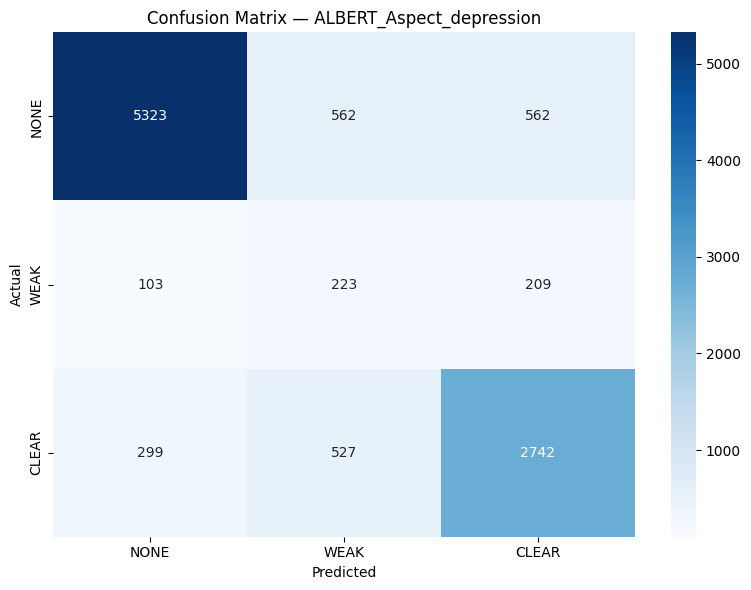


ALBERT — ANXIETY (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9590    0.8628    0.9083      8314
        WEAK     0.1496    0.3960    0.2172       351
       CLEAR     0.6833    0.7761    0.7268      1885

    accuracy                         0.8318     10550
   macro avg     0.5973    0.6783    0.6174     10550
weighted avg     0.8828    0.8318    0.8529     10550

Weighted F1: 0.8529  95% CI [0.8469, 0.8591]
Macro F1:    0.6174  95% CI [0.6050, 0.6299]
Saved → outputs/06_AspectLabel/ALBERT_Aspect_anxiety_confusion_matrix.png


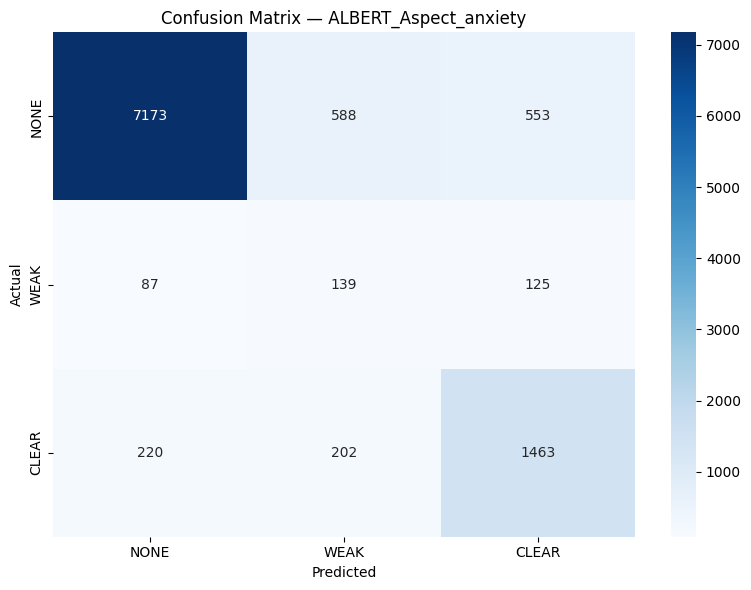


ALBERT — SUICIDAL (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9590    0.8877    0.9220      7887
        WEAK     0.1062    0.3333    0.1611       201
       CLEAR     0.7889    0.8392    0.8132      2462

    accuracy                         0.8658     10550
   macro avg     0.6180    0.6867    0.6321     10550
weighted avg     0.9031    0.8658    0.8821     10550

Weighted F1: 0.8821  95% CI [0.8761, 0.8878]
Macro F1:    0.6321  95% CI [0.6196, 0.6448]
Saved → outputs/06_AspectLabel/ALBERT_Aspect_suicidal_confusion_matrix.png


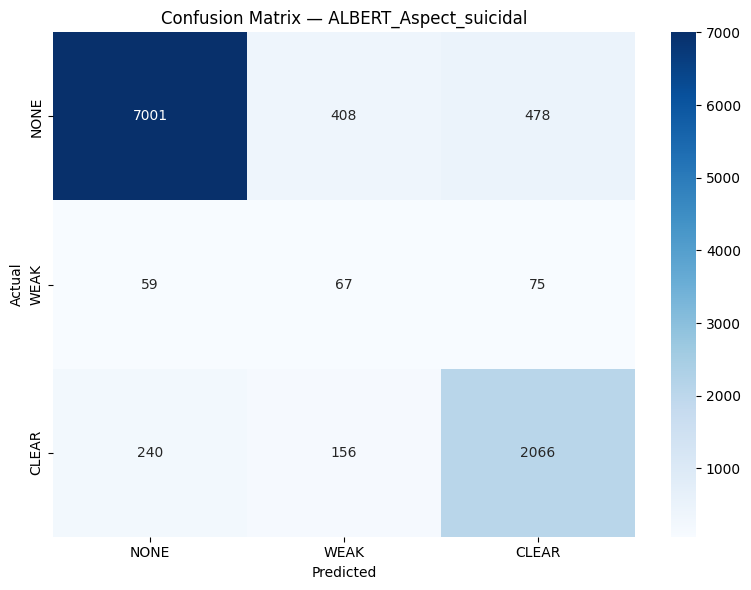


ALBERT — STRESS (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9261    0.6739    0.7801      8531
        WEAK     0.2084    0.5299    0.2991      1189
       CLEAR     0.3958    0.6289    0.4858       830

    accuracy                         0.6541     10550
   macro avg     0.5101    0.6109    0.5217     10550
weighted avg     0.8035    0.6541    0.7027     10550

Weighted F1: 0.7027  95% CI [0.6951, 0.7106]
Macro F1:    0.5217  95% CI [0.5097, 0.5327]
Saved → outputs/06_AspectLabel/ALBERT_Aspect_stress_confusion_matrix.png


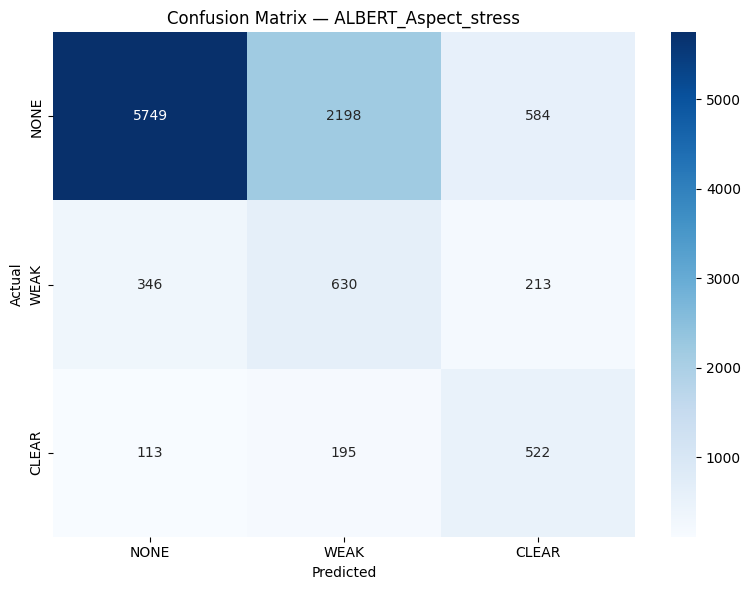


ALBERT — BIPOLAR (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9960    0.9784    0.9871     10196
        WEAK     0.1186    0.2875    0.1679        80
       CLEAR     0.6441    0.7993    0.7134       274

    accuracy                         0.9685     10550
   macro avg     0.5862    0.6884    0.6228     10550
weighted avg     0.9802    0.9685    0.9738     10550

Weighted F1: 0.9738  95% CI [0.9710, 0.9765]
Macro F1:    0.6228  95% CI [0.5985, 0.6480]
Saved → outputs/06_AspectLabel/ALBERT_Aspect_bipolar_confusion_matrix.png


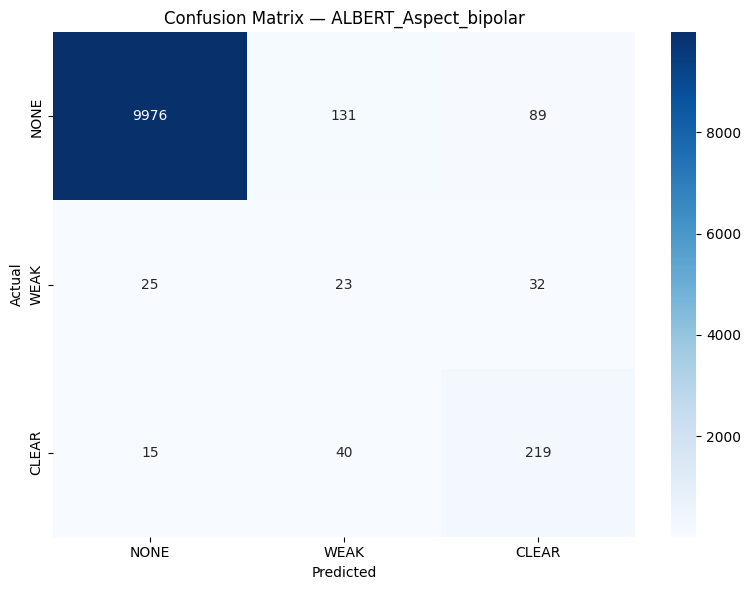


ALBERT — PERSONALITY_DISORDER (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9890    0.9594    0.9740     10276
        WEAK     0.1142    0.2885    0.1636       156
       CLEAR     0.3797    0.6017    0.4656       118

    accuracy                         0.9455     10550
   macro avg     0.4943    0.6165    0.5344     10550
weighted avg     0.9692    0.9455    0.9563     10550

Weighted F1: 0.9563  95% CI [0.9523, 0.9599]
Macro F1:    0.5344  95% CI [0.5086, 0.5612]
Saved → outputs/06_AspectLabel/ALBERT_Aspect_personality_disorder_confusion_matrix.png


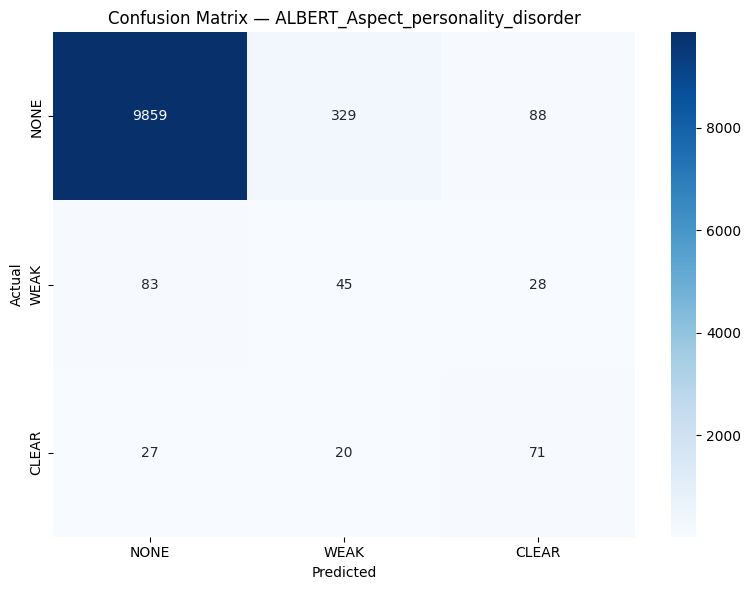

In [20]:
albert_results = evaluate_aspects(
    best_albert, test_loader_albert, "ALBERT", save_dir=str(OUTPUT_PATH)
)

## 3.5 BioBERT: Soft-label training

In [21]:
print("\n" + "=" * 60)
print("BioBERT — Multi-Task Training")
print("=" * 60)


BioBERT — Multi-Task Training


### 3.5.1 Pre-tokenize

In [22]:
biobert_tokenizer = AutoTokenizer.from_pretrained(BIOBERT_MODEL_NAME)
train_loader_biobert, val_loader_biobert, test_loader_biobert = \
    build_loaders(biobert_tokenizer, "BioBERT")

config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Tokenizing for BioBERT...


### 3.5.2 Hyperparameter tuning

In [23]:
if RETRAIN:
    set_seed(RUN_SEED)
    start = time.time()

    best_f1_biobert, best_params_biobert, best_biobert = -1.0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Aspect random search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*TRANSFORMER_PARAM_SPACE["lr"])),
            "epochs": int(np.random.randint(*TRANSFORMER_PARAM_SPACE["epochs"])),
            "dropout": float(np.random.uniform(*TRANSFORMER_PARAM_SPACE["dropout"])),
        }
        print(f"BioBERT trial {i + 1}/{N_ITERATIONS}: {hp}")

        base = AutoModel.from_pretrained(BIOBERT_MODEL_NAME)
        model = AspectTransformer(
            base, base.config.hidden_size, dropout=hp["dropout"],
        )

        f1_val, model, best_ep = train_aspect_model(
            model, train_loader_biobert, val_loader_biobert,
            aspect_weights,
            lr=hp["lr"], max_epochs=hp["epochs"], hp=hp,
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = {"seed": RUN_SEED, "trial": i + 1, "best_epoch": best_ep, **hp}
            best_biobert = model
            torch.save(model.state_dict(), MODEL_PATHS["biobert"]["model"])
            with open(MODEL_PATHS["biobert"]["params"], "w") as _pf:
                json.dump(best_params_biobert, _pf, indent=2)
            print(f"  New best BioBERT: ValF1={f1_val:.4f}")

        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT random search: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")

    with open(MODEL_PATHS["biobert"]["params"], "w") as f:
        json.dump(best_params_biobert, f, indent=2)

else:
    with open(MODEL_PATHS["biobert"]["params"]) as f:
        best_params_biobert = json.load(f)
    base = AutoModel.from_pretrained(BIOBERT_MODEL_NAME)
    best_biobert = AspectTransformer(
        base, base.config.hidden_size, dropout=best_params_biobert.get("dropout", 0.1),
    )
    best_biobert.load_state_dict(torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE))

best_biobert.to(DEVICE)
best_biobert.eval()


BioBERT Aspect random search:   0%|          | 0/10 [00:00<?, ?it/s]

BioBERT trial 1/10: {'lr': 1.160497696239576e-05, 'epochs': 6, 'dropout': 0.08535068283342875}


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  433MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Epoch 1/9 | Loss=5.8573 | MeanF1=0.7848 | depression=0.731 | anxiety=0.719 | suicidal=0.825 | stress=0.703 | bipolar=0.918 | personality_disorder=0.812
  Epoch 2/9 | Loss=4.4324 | MeanF1=0.8211 | depression=0.767 | anxiety=0.795 | suicidal=0.795 | stress=0.690 | bipolar=0.960 | personality_disorder=0.919
  Epoch 3/9 | Loss=3.8326 | MeanF1=0.8324 | depression=0.799 | anxiety=0.818 | suicidal=0.859 | stress=0.691 | bipolar=0.968 | personality_disorder=0.859
  Epoch 4/9 | Loss=3.2991 | MeanF1=0.8348 | depression=0.783 | anxiety=0.782 | suicidal=0.860 | stress=0.681 | bipolar=0.970 | personality_disorder=0.932
  Epoch 5/9 | Loss=2.7989 | MeanF1=0.8466 | depression=0.796 | anxiety=0.817 | suicidal=0.867 | stress=0.702 | bipolar=0.970 | personality_disorder=0.927
  Epoch 6/9 | Loss=2.4190 | MeanF1=0.8472 | depression=0.788 | anxiety=0.830 | suicidal=0.876 | stress=0.676 | bipolar=0.964 | personality_disorder=0.950
  Epoch 7/9 | Loss=2.1333 | MeanF1=0.8530 | depression=0.797 | anxiety=0.843

BioBERT Aspect random search: 100%|██████████| 10/10 [3:28:08<00:00, 1248.80s/it]

  New best BioBERT: ValF1=0.8581
BioBERT random search: 12488.0s | Best F1=0.8581
Best params: {'seed': 2025, 'trial': 10, 'best_epoch': 9, 'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563, 'dropout_modules': {'base.embeddings.dropout': 0.1, 'base.encoder.layer.0.attention.self.dropout': 0.1, 'base.encoder.layer.0.attention.output.dropout': 0.1, 'base.encoder.layer.0.output.dropout': 0.1, 'base.encoder.layer.1.attention.self.dropout': 0.1, 'base.encoder.layer.1.attention.output.dropout': 0.1, 'base.encoder.layer.1.output.dropout': 0.1, 'base.encoder.layer.2.attention.self.dropout': 0.1, 'base.encoder.layer.2.attention.output.dropout': 0.1, 'base.encoder.layer.2.output.dropout': 0.1, 'base.encoder.layer.3.attention.self.dropout': 0.1, 'base.encoder.layer.3.attention.output.dropout': 0.1, 'base.encoder.layer.3.output.dropout': 0.1, 'base.encoder.layer.4.attention.self.dropout': 0.1, 'base.encoder.layer.4.attention.output.dropout': 0.1, 'base.encoder.layer.4.output

AspectTransformer(
  (base): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise

### 3.5.3 Model Evaluation


BioBERT — DEPRESSION (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9344    0.8103    0.8679      6447
        WEAK     0.1585    0.5047    0.2413       535
       CLEAR     0.7951    0.7256    0.7588      3568

    accuracy                         0.7662     10550
   macro avg     0.6293    0.6802    0.6227     10550
weighted avg     0.8479    0.7662    0.7992     10550

Weighted F1: 0.7992  95% CI [0.7921, 0.8066]
Macro F1:    0.6227  95% CI [0.6120, 0.6323]
Saved → outputs/06_AspectLabel/BioBERT_Aspect_depression_confusion_matrix.png


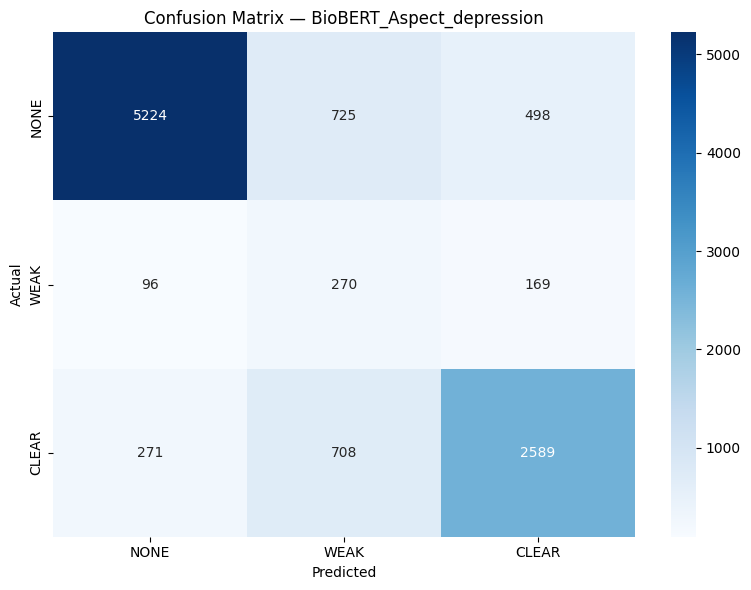


BioBERT — ANXIETY (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9580    0.8500    0.9008      8314
        WEAK     0.1328    0.4587    0.2060       351
       CLEAR     0.7104    0.7390    0.7244      1885

    accuracy                         0.8172     10550
   macro avg     0.6004    0.6826    0.6104     10550
weighted avg     0.8863    0.8172    0.8461     10550

Weighted F1: 0.8461  95% CI [0.8395, 0.8525]
Macro F1:    0.6104  95% CI [0.5995, 0.6214]
Saved → outputs/06_AspectLabel/BioBERT_Aspect_anxiety_confusion_matrix.png


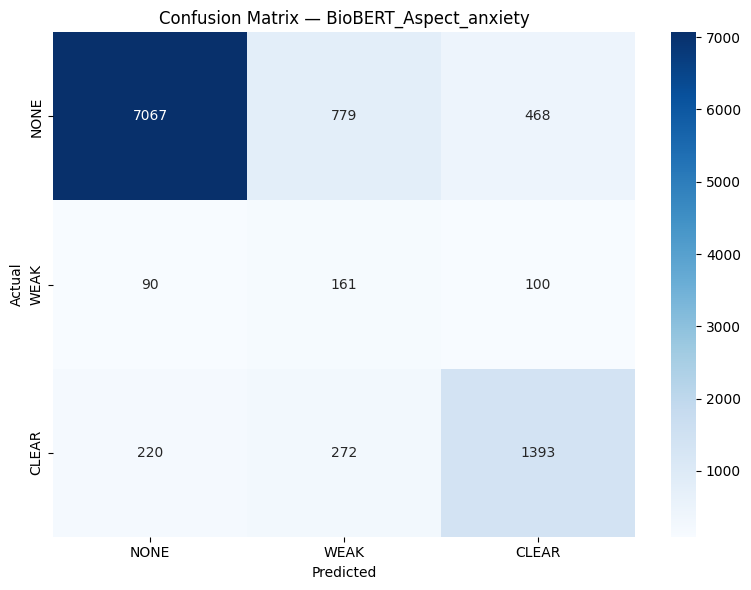


BioBERT — SUICIDAL (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9639    0.8737    0.9166      7887
        WEAK     0.1175    0.3582    0.1769       201
       CLEAR     0.7543    0.8542    0.8011      2462

    accuracy                         0.8593     10550
   macro avg     0.6119    0.6954    0.6315     10550
weighted avg     0.8989    0.8593    0.8756     10550

Weighted F1: 0.8756  95% CI [0.8695, 0.8815]
Macro F1:    0.6315  95% CI [0.6176, 0.6444]
Saved → outputs/06_AspectLabel/BioBERT_Aspect_suicidal_confusion_matrix.png


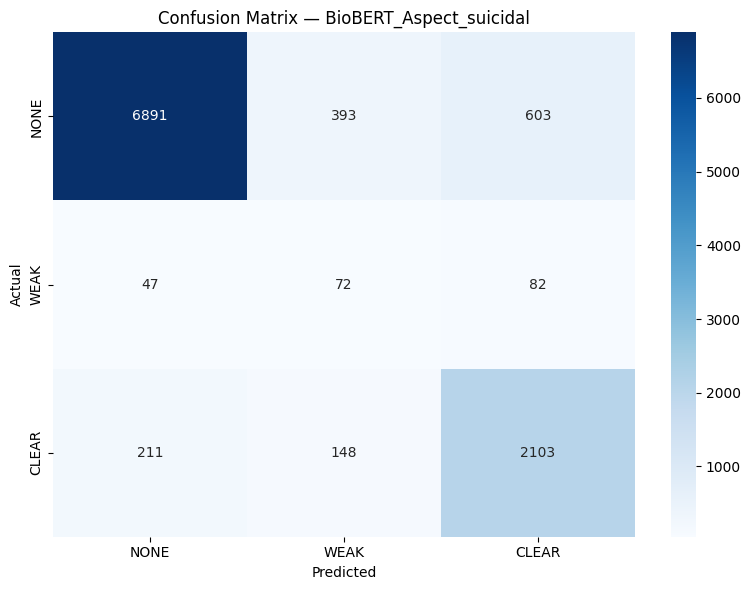


BioBERT — STRESS (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9298    0.6569    0.7699      8531
        WEAK     0.2079    0.5315    0.2989      1189
       CLEAR     0.3587    0.6410    0.4600       830

    accuracy                         0.6415     10550
   macro avg     0.4988    0.6098    0.5096     10550
weighted avg     0.8035    0.6415    0.6924     10550

Weighted F1: 0.6924  95% CI [0.6846, 0.7004]
Macro F1:    0.5096  95% CI [0.4986, 0.5207]
Saved → outputs/06_AspectLabel/BioBERT_Aspect_stress_confusion_matrix.png


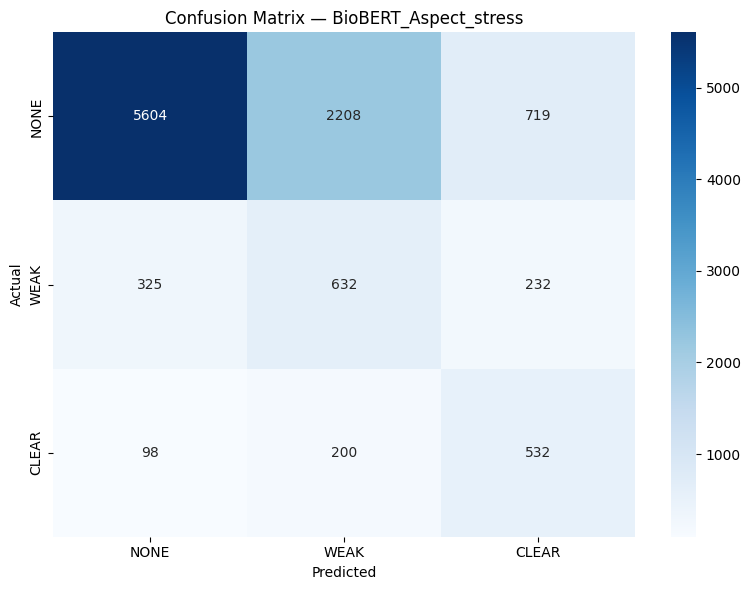


BioBERT — BIPOLAR (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9963    0.9774    0.9868     10196
        WEAK     0.1327    0.3250    0.1884        80
       CLEAR     0.6752    0.8650    0.7584       274

    accuracy                         0.9696     10550
   macro avg     0.6014    0.7225    0.6445     10550
weighted avg     0.9814    0.9696    0.9748     10550

Weighted F1: 0.9748  95% CI [0.9721, 0.9775]
Macro F1:    0.6445  95% CI [0.6205, 0.6697]
Saved → outputs/06_AspectLabel/BioBERT_Aspect_bipolar_confusion_matrix.png


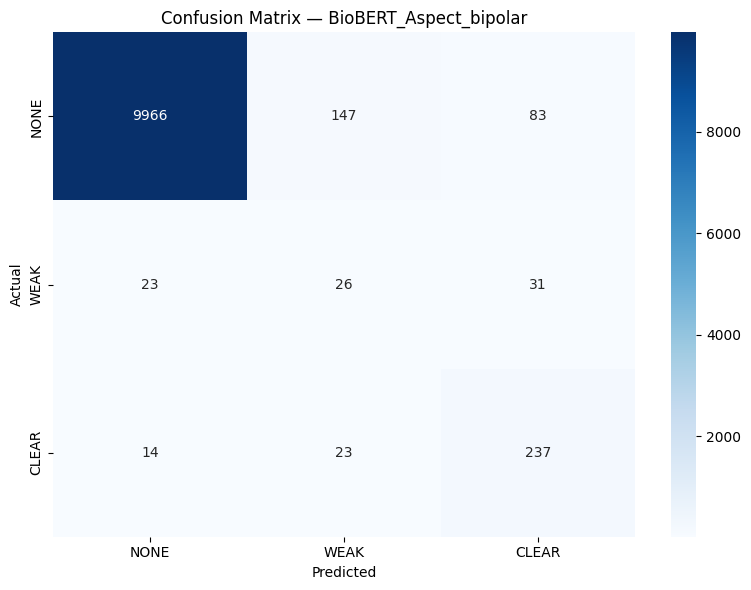


BioBERT — PERSONALITY_DISORDER (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9905    0.9574    0.9737     10276
        WEAK     0.1138    0.3013    0.1652       156
       CLEAR     0.3220    0.5593    0.4087       118

    accuracy                         0.9432     10550
   macro avg     0.4754    0.6060    0.5158     10550
weighted avg     0.9701    0.9432    0.9554     10550

Weighted F1: 0.9554  95% CI [0.9517, 0.9588]
Macro F1:    0.5158  95% CI [0.4891, 0.5442]
Saved → outputs/06_AspectLabel/BioBERT_Aspect_personality_disorder_confusion_matrix.png


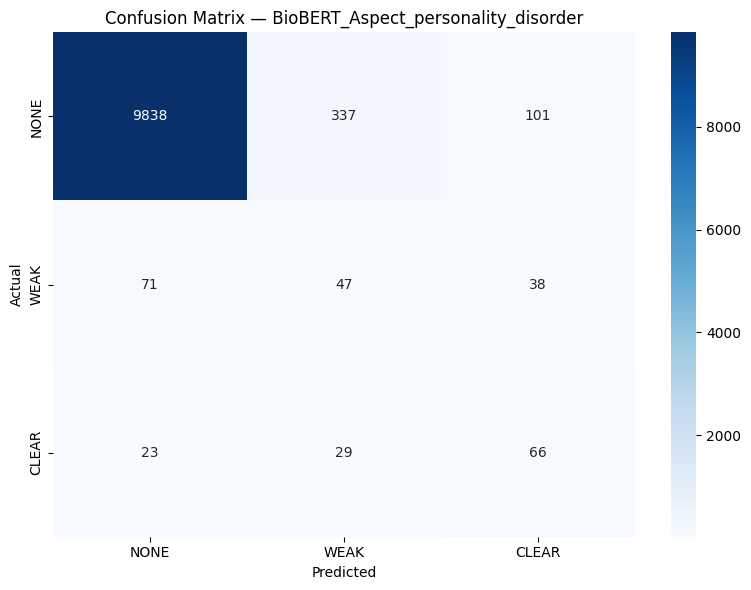

In [24]:
biobert_results = evaluate_aspects(
    best_biobert, test_loader_biobert, "BioBERT", save_dir=str(OUTPUT_PATH)
)

## 3.6 Save Prediction

In [25]:
df_test_out = df_test[["id", TEXT_COLUMN]].copy()

# Aspect predictions
for asp in ASPECT_NAMES:
    short = asp_display(asp)
    df_test_out[f"albert_{short}_pred"] = albert_results[asp]["y_pred"]
    df_test_out[f"biobert_{short}_pred"] = biobert_results[asp]["y_pred"]
    df_test_out[f"{short}_true"] = albert_results[asp]["y_true"]

pred_path = OUTPUT_PATH / "test_predictions_aspect.csv"
df_test_out.to_csv(pred_path, index=False)
print(f"\nSaved predictions → {pred_path}")

# ── Summary ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY — Aspect-Only 3-Class (Mental Health)")
print("=" * 60)
for model_name, results in [("ALBERT", albert_results), ("BioBERT", biobert_results)]:
    print(f"\n{model_name}:")
    f1s = []
    f1s_mac = []
    for asp in ASPECT_NAMES:
        r = results[asp]
        short = asp_display(asp)
        print(f"  {short:25s} weighted F1: {r['f1_weighted']:.4f} "
              f"[{r['f1_ci'][0]:.4f}, {r['f1_ci'][1]:.4f}]"
              f"   macro F1: {r['f1_macro']:.4f} "
              f"[{r['f1_macro_ci'][0]:.4f}, {r['f1_macro_ci'][1]:.4f}]")
        f1s.append(r['f1_weighted'])
        f1s_mac.append(r['f1_macro'])
    print(f"  {'MEAN':25s} weighted F1: {np.mean(f1s):.4f}   macro F1: {np.mean(f1s_mac):.4f}")


Saved predictions → outputs/06_AspectLabel/test_predictions_aspect.csv

SUMMARY — Aspect-Only 3-Class (Mental Health)

ALBERT:
  depression                weighted F1: 0.8086 [0.8013, 0.8161]   macro F1: 0.6302 [0.6201, 0.6404]
  anxiety                   weighted F1: 0.8529 [0.8469, 0.8591]   macro F1: 0.6174 [0.6050, 0.6299]
  suicidal                  weighted F1: 0.8821 [0.8761, 0.8878]   macro F1: 0.6321 [0.6196, 0.6448]
  stress                    weighted F1: 0.7027 [0.6951, 0.7106]   macro F1: 0.5217 [0.5097, 0.5327]
  bipolar                   weighted F1: 0.9738 [0.9710, 0.9765]   macro F1: 0.6228 [0.5985, 0.6480]
  personality_disorder      weighted F1: 0.9563 [0.9523, 0.9599]   macro F1: 0.5344 [0.5086, 0.5612]
  MEAN                      weighted F1: 0.8627   macro F1: 0.5931

BioBERT:
  depression                weighted F1: 0.7992 [0.7921, 0.8066]   macro F1: 0.6227 [0.6120, 0.6323]
  anxiety                   weighted F1: 0.8461 [0.8395, 0.8525]   macro F1: 0.6104 [0.5